# 09 · All-layer diagnostics

In [1]:
# All-layer diagnostic view: gains, selected hooks, near-best bands, and ridge regularization.
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
set_style()
pd.set_option("display.precision", 3)

model = pd.read_csv(ROOT / "reports/sae_prediction/model_comparison.csv")
selection = pd.read_csv(ROOT / "reports/sae_prediction/hook_selection.csv")
reg = pd.read_csv(ROOT / "reports/sae_prediction/regularization_summary.csv")
layer = model[model.label != "inner_selected"].copy()
for col in ["delta_r2", "ci_low", "ci_high"]:
    layer[col + "_pp"] = 100 * layer[col]
layer["layer_idx"] = layer.label.map({h: i for i, h in enumerate(HOOK_ORDER)})

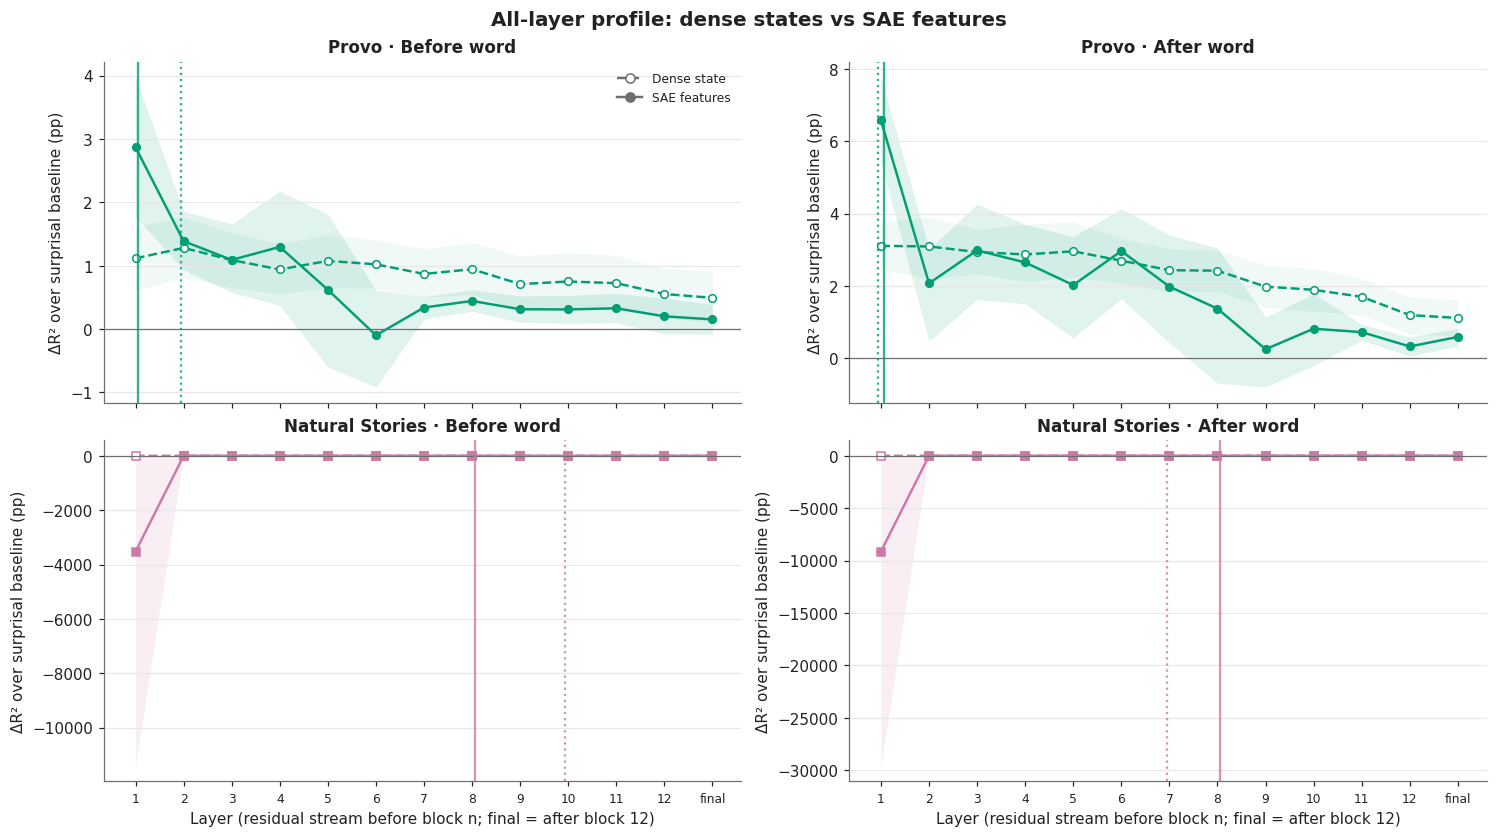

In [2]:
# Layer-wise held-out gain: selected layers are evidence, but broad bands matter too.
fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.5), layout="constrained", sharex=True, sharey=False)
for row, corpus in enumerate(CORPORA):
    for col, kind in enumerate(["prefix", "post"]):
        ax = axes[row, col]
        sub = layer[(layer.corpus == corpus) & (layer.kind == kind)]
        layer_profile(ax, sub.rename(columns={"representation": "rep", "delta_r2_pp": "est", "ci_low_pp": "lo", "ci_high_pp": "hi"})[["label", "rep", "est", "lo", "hi"]], corpus)
        for rep, offset in [("sae", 0.06), ("dense", -0.06)]:
            sel = selection[(selection.corpus == corpus) & (selection.kind == kind) & (selection.representation == rep)]
            if len(sel):
                top = sel.sort_values("fold_count", ascending=False).iloc[0]
                if top.label in HOOK_ORDER:
                    ax.axvline(HOOK_ORDER.index(top.label) + offset, color=CORPUS_COLORS[corpus], ls=":" if rep == "dense" else "-", lw=1.5, alpha=0.8)
        ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · {STATE_LABELS[kind]}")
        ax.set_ylabel("ΔR² over surprisal baseline (pp)")
        if row == 0:
            ax.set_xlabel("")
rep_legend(axes[0,0], ("dense", "sae"), fontsize=8, loc="upper right")
fig.suptitle("All-layer profile: dense states vs SAE features", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "09_all_layer_gain_profiles")
plt.show()

In [3]:
# Is the selected layer isolated, or part of a broader near-best band?
rows = []
for corpus in CORPORA:
    for kind in ["prefix", "post"]:
        for rep in ["dense", "sae"]:
            sub = layer[(layer.corpus == corpus) & (layer.kind == kind) & (layer.representation == rep)].copy()
            sub = sub.sort_values("delta_r2_pp", ascending=False)
            best = sub.iloc[0]
            second = sub.iloc[1]
            band_05 = sub[sub.delta_r2_pp >= best.delta_r2_pp - 0.5].label.tolist()
            band_10 = sub[sub.delta_r2_pp >= best.delta_r2_pp - 1.0].label.tolist()
            sel = selection[(selection.corpus == corpus) & (selection.kind == kind) & (selection.representation == rep)].copy()
            total = int(model[(model.corpus == corpus) & (model.kind == kind) & (model.representation == rep) & (model.label == "inner_selected")].n_texts.iloc[0])
            sel["pct"] = 100 * sel.fold_count / total
            selected = "; ".join(f"{r.label} ({r.pct:.0f}%)" for r in sel.sort_values("fold_count", ascending=False).itertuples())
            rows.append({
                "Dataset": CORPUS_LABELS[corpus].split(" ·")[0],
                "State": STATE_LABELS[kind],
                "Representation": REP_LABELS[rep],
                "Best layer by gain": best.label,
                "Best gain (pp)": best.delta_r2_pp,
                "2nd best": second.label,
                "Margin vs 2nd (pp)": best.delta_r2_pp - second.delta_r2_pp,
                "Near-best ≤0.5pp": ", ".join(band_05),
                "Near-best ≤1pp": ", ".join(band_10),
                "Inner-CV selected hooks": selected,
            })
band_table = pd.DataFrame(rows)
display(focus_table(band_table.round({"Best gain (pp)": 2, "Margin vs 2nd (pp)": 2}),
                    important=["Best gain (pp)", "Margin vs 2nd (pp)", "Inner-CV selected hooks"],
                    signed_columns=["Best gain (pp)", "Margin vs 2nd (pp)"],
                    formats={"Best gain (pp)": "{:+.2f}", "Margin vs 2nd (pp)": "{:+.2f}"},
                    caption="Near-best bands help avoid overclaiming one exact layer when neighboring layers are similar."))

Dataset,State,Representation,Best layer by gain,Best gain (pp),2nd best,Margin vs 2nd (pp),Near-best ≤0.5pp,Near-best ≤1pp,Inner-CV selected hooks
Provo,Before word,Dense state,L02,+1.28,L01,+0.16,"L02, L01, L03, L05, L06, L08, L04, L07","L02, L01, L03, L05, L06, L08, L04, L07, L10, L11, L09, L12, final_resid_post",L02 (85%); L01 (13%); L08 (2%)
Provo,Before word,SAE features,L01,+2.87,L02,+1.48,L01,L01,L01 (100%)
Provo,After word,Dense state,L01,+3.11,L02,+0.02,"L01, L02, L05, L03, L04, L06","L01, L02, L05, L03, L04, L06, L07, L08",L01 (73%); L02 (24%); L05 (4%)
Provo,After word,SAE features,L01,+6.58,L03,+3.59,L01,L01,L01 (100%)
Natural Stories,Before word,Dense state,L04,+3.22,L03,+0.13,"L04, L03, L06","L04, L03, L06, L05, L02, L07",L10 (40%); L06 (20%); L07 (20%); L04 (10%); L08 (10%)
Natural Stories,Before word,SAE features,L06,+1.79,L05,+0.06,"L06, L05, L07, L04","L06, L05, L07, L04, L03, L10, L09, L08, final_resid_post, L12",L08 (40%); L04 (20%); L02 (10%); L03 (10%); L05 (10%); L06 (10%)
Natural Stories,After word,Dense state,L04,+6.61,L07,+0.18,"L04, L07, L08, L06, L03, L05","L04, L07, L08, L06, L03, L05, L09, L10",L07 (30%); L04 (20%); L06 (20%); L08 (20%); L03 (10%)
Natural Stories,After word,SAE features,L08,+4.30,L07,+0.37,"L08, L07","L08, L07, L05, L10, L04",L08 (50%); L05 (20%); L07 (10%); L09 (10%); L10 (10%)


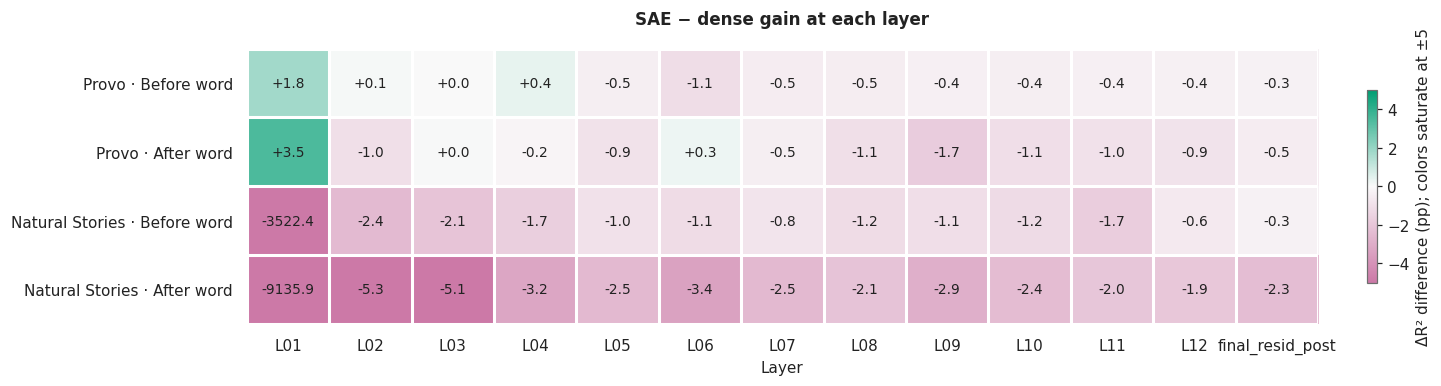

label,L01,L02,L03,L04,L05,L06,L07,L08,L09,L10,L11,L12,final_resid_post
Provo · Before word,1.75,0.11,0.00,0.36,-0.46,-1.12,-0.53,-0.50,-0.40,-0.44,-0.40,-0.35,-0.34
Provo · After word,3.47,-1.02,0.05,-0.22,-0.93,0.27,-0.46,-1.05,-1.73,-1.08,-0.98,-0.87,-0.52
Natural Stories · Before word,-3522.45,-2.42,-2.05,-1.67,-0.97,-1.14,-0.83,-1.16,-1.08,-1.21,-1.70,-0.63,-0.31
Natural Stories · After word,-9135.90,-5.29,-5.14,-3.23,-2.49,-3.40,-2.48,-2.09,-2.89,-2.38,-1.96,-1.93,-2.33


In [4]:
# SAE minus dense by layer: positive means the sparse readout beats the dense state at the same hook.
diff_rows = []
for corpus in CORPORA:
    for kind in ["prefix", "post"]:
        a = layer[(layer.corpus == corpus) & (layer.kind == kind)].pivot(index="label", columns="representation", values="delta_r2_pp").reindex(HOOK_ORDER)
        diff_rows.append(pd.Series(a["sae"] - a["dense"], name=f"{CORPUS_LABELS[corpus].split(' ·')[0]} · {STATE_LABELS[kind]}"))
diff = pd.DataFrame(diff_rows)
fig, ax = plt.subplots(figsize=(13, 3.4), layout="constrained")
annotated_heatmap(ax, diff, fmt="+.1f", signed=True, norm=Normalize(-5, 5), title="SAE − dense gain at each layer", colorbar_label="ΔR² difference (pp); colors saturate at ±5")
ax.set_xlabel("Layer")
save_figure(fig, FIG, "09_sae_minus_dense_layer_heatmap")
plt.show()
display(diff.round(2))

In [5]:
# Regularization audit: ridge alpha is selected inside inner CV; controls/surprisal are unpenalized by design.
reg_table = reg.copy()
reg_table["Dataset"] = reg_table.corpus.map(lambda c: CORPUS_LABELS[c].split(" ·")[0])
reg_table["State"] = reg_table.kind.map(STATE_LABELS)
reg_table["Representation"] = reg_table.representation.map(REP_LABELS)
reg_table = reg_table[["Dataset", "State", "Representation", "fits", "smallest_alpha_choices", "largest_alpha_choices"]]
display(focus_table(reg_table, important=["fits", "smallest_alpha_choices", "largest_alpha_choices"],
                    caption="Ridge regularization audit. Alpha is chosen by inner-validation MSE; controls and surprisal are unpenalized."))

Dataset,State,Representation,fits,smallest_alpha_choices,largest_alpha_choices
Natural Stories,After word,Dense state,130,0,0
Natural Stories,After word,SAE features,130,0,17
Natural Stories,Before word,Dense state,130,0,1
Natural Stories,Before word,SAE features,130,0,53
Provo,After word,Dense state,715,0,0
Provo,After word,SAE features,715,0,246
Provo,Before word,Dense state,715,0,4
Provo,Before word,SAE features,715,0,419
